In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("churn.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
df.drop("customerID", axis=1, inplace=True)

In [7]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].fillna(
    df["TotalCharges"].mean(),
    inplace=True
)

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

In [9]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


In [12]:
predictions = model.predict(X_test)

print(predictions[:10])

[1 0 0 1 0 0 0 0 0 0]


In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.7955997161107168


In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[941  95]
 [193 180]]


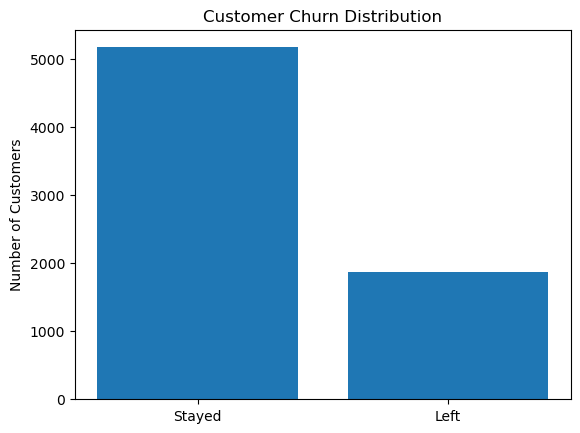

In [15]:
churn_counts = df["Churn"].value_counts()

plt.bar(
    ["Stayed", "Left"],
    churn_counts
)

plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
importance = model.feature_importances_

feature_names = X.columns

feature_data = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_data = feature_data.sort_values(
    by="Importance",
    ascending=False
)

print(feature_data.head(10))

             Feature  Importance
18      TotalCharges    0.190546
17    MonthlyCharges    0.180420
4             tenure    0.155694
14          Contract    0.078417
16     PaymentMethod    0.051666
8     OnlineSecurity    0.049381
11       TechSupport    0.035536
9       OnlineBackup    0.029453
0             gender    0.027939
15  PaperlessBilling    0.026401


INSIGHTS

1. Contract type and monthly charges strongly affect customer churn.
2. Customers with higher monthly charges are more likely to leave.
3. Random Forest classifier performed effectively for churn prediction.
4. Feature importance helped identify major churn factors.

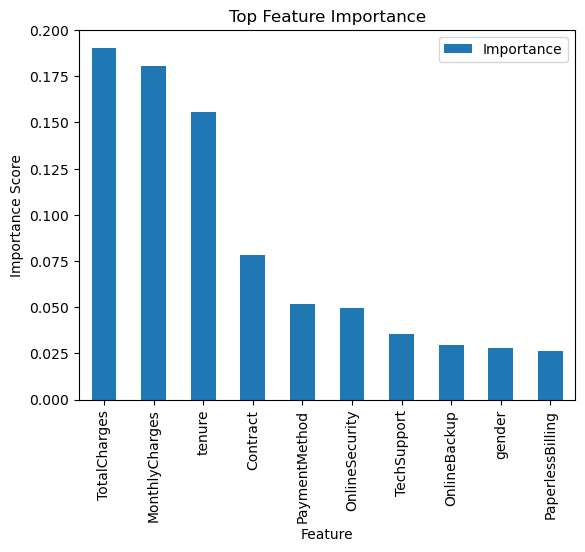

In [17]:
feature_data.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top Feature Importance")
plt.ylabel("Importance Score")

plt.show()

In [18]:
churn_percentage = (
    df["Churn"].value_counts(normalize=True) * 100
)

print(churn_percentage)

0    73.463013
1    26.536987
Name: Churn, dtype: float64


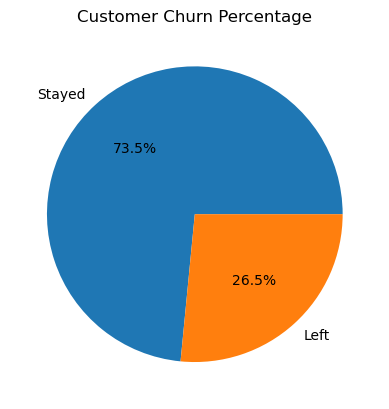

In [19]:
plt.pie(
    churn_counts,
    labels=["Stayed", "Left"],
    autopct="%1.1f%%"
)

plt.title("Customer Churn Percentage")

plt.show()

In [22]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8140525195173882


In [23]:
print("Random Forest Accuracy:", accuracy)

print("Logistic Regression Accuracy:", lr_accuracy)

Random Forest Accuracy: 0.7955997161107168
Logistic Regression Accuracy: 0.8140525195173882


CONCLUSION

1. Random Forest performed better than Logistic Regression for churn prediction.
2. Monthly charges and contract type were major churn indicators.
3. Machine learning can help businesses identify customers likely to leave.
4. Data preprocessing and feature encoding improved model performance.